In [1]:
!pip install matplotlib seaborn
!pip install streamlit seaborn pandas numpy
!pip install plotly


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

In [3]:
df = pd.read_csv("../data/ev_market_2026.csv")
df

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BMW,i3,2023,Long Range,122665.71,102.1,360.0,92.0,4.21,190.0,...,Hatchback,38.3,1500.0,5,2,Germany,Luxury,66187,3.78,7
1996,Toyota,bZ4X,2024,Performance,66816.55,110.6,367.0,236.3,4.25,181.0,...,Hatchback,23.1,1863.0,4,0,Japan,Premium,11062,3.79,4
1997,Tesla,Model 3,2025,Long Range,49281.26,90.6,325.0,325.6,5.55,167.0,...,Truck,74.6,2920.0,3,3,US,Mid-range,224804,4.10,6
1998,Tesla,Model X,2026,Premium,139665.73,70.7,248.0,330.7,5.07,175.0,...,Coupe,34.8,1500.0,3,2,US,Luxury,165373,3.66,4


In [4]:
#Total jualan brand
df["brand"].value_counts()

brand
Tesla           434
BYD             282
Volkswagen      194
Kia             166
Hyundai         152
BMW             150
GM/Chevrolet    143
Ford            129
Mercedes         96
Audi             77
Toyota           41
Rivian           37
Fisker           25
NIO              23
Porsche          14
Volvo            12
Polestar          9
Xiaomi            8
Lucid             6
Honda             2
Name: count, dtype: int64

In [5]:
#ratimg setiap brand by model

df.sort_values("customer_rating", ascending=False)[
    ["brand", "model", "customer_rating"]
].head()

,brand,model,customer_rating
960,Tesla,Model Y,4.51
703,Tesla,Model 3,4.42
1541,Tesla,Model S,4.42
1342,Mercedes,GLE EV,4.39
1716,Tesla,Cybertruck,4.38


In [6]:
#EV PALING MAHAL
ev_exp =df.sort_values("price_usd", ascending=False)[
    ["brand", "model", "year", "battery_capacity_kwh", "country_of_origin", "market_segment", "customer_rating",  "safety_rating"]].head
ev_exp

<bound method NDFrame.head of          brand    model  year  battery_capacity_kwh country_of_origin  \
1334     Lucid      Air  2024                  76.3                US   
518    Porsche   Taycan  2023                 118.1           Germany   
1466     Lucid      Air  2026                  63.1                US   
446    Porsche   Taycan  2026                  82.6           Germany   
12    Mercedes      EQG  2025                  93.2           Germany   
...        ...      ...   ...                   ...               ...   
1603       BYD   Atto 3  2024                  44.4             China   
753        BYD  Seagull  2024                  53.5             China   
852        BYD      Qin  2024                  78.0             China   
1055       BYD  Seagull  2024                  55.9             China   
13         BYD  Seagull  2023                  41.8             China   

     market_segment  customer_rating  safety_rating  
1334         Luxury             3.28   

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#AVG BRAND

avg_price = df.groupby("brand")["price_usd"].mean().reset_index()
print(avg_price)

           brand      price_usd
0           Audi   93875.340130
1            BMW   98062.344067
2            BYD   60084.840957
3         Fisker   88699.359200
4           Ford   65199.069070
5   GM/Chevrolet   57247.111888
6          Honda   55985.645000
7        Hyundai   60454.971053
8            Kia   65835.655301
9          Lucid  192516.878333
10      Mercedes  128717.874271
11           NIO   84526.814348
12      Polestar   89828.097778
13       Porsche  157050.798571
14        Rivian   89973.977568
15         Tesla   93522.975645
16        Toyota   65738.328049
17    Volkswagen   67915.328763
18         Volvo   78206.630000
19        Xiaomi   78894.801250


In [9]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
corelasi_df = df.select_dtypes(include="number")

corelasi_df.corr()


#Mendekati 1	sangat berhubungan
#Mendekati 0	tidak ada hubungan
#Mendekati -1	berhubungan tapi berlawanan

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
year,1.000000,0.065604,-0.018653,-0.010605,0.022345,0.014385,-0.014974,0.080867,0.078481,0.043233,-0.023846,0.011005,-0.030302,0.015391,0.003734,0.005815,0.035789
price_usd,0.065604,1.000000,0.163565,0.156174,0.302888,-0.172457,0.164290,0.764724,0.759726,0.023512,-0.000737,0.006261,0.027652,0.257110,-0.030502,0.298409,0.396250
battery_capacity_kwh,-0.018653,0.163565,1.000000,0.977859,0.155309,-0.606528,0.592145,0.199032,0.197377,-0.003692,0.018981,0.034911,0.024168,-0.021736,-0.006791,0.658008,-0.004284
range_miles,-0.010605,0.156174,0.977859,1.000000,0.148906,-0.592191,0.577426,0.192405,0.190323,-0.005804,0.018149,0.036884,0.030825,-0.026423,-0.012127,0.668137,-0.010557
charging_speed_kw,0.022345,0.302888,0.155309,0.148906,1.000000,-0.222219,0.200766,0.073125,0.073153,0.028932,0.056504,0.073468,-0.022332,0.519870,0.401654,0.447148,0.135887
acceleration_0_60_mph,0.014385,-0.172457,-0.606528,-0.592191,-0.222219,1.000000,-0.970953,-0.227614,-0.226616,-0.004088,0.022828,-0.015251,0.007723,0.032428,0.019917,-0.377177,0.040619
top_speed_mph,-0.014974,0.164290,0.592145,0.577426,0.200766,-0.970953,1.000000,0.217379,0.216991,0.003859,-0.028282,0.002589,-0.009063,-0.036581,-0.023985,0.366117,-0.041165
horsepower,0.080867,0.764724,0.199032,0.192405,0.073125,-0.227614,0.217379,1.000000,0.991827,0.003683,0.007445,-0.000243,0.012050,-0.014193,-0.067041,0.134986,0.042018
torque_nm,0.078481,0.759726,0.197377,0.190323,0.073153,-0.226616,0.216991,0.991827,1.000000,0.000426,0.003876,-0.001058,0.009741,-0.014091,-0.064073,0.132197,0.042297
seating_capacity,0.043233,0.023512,-0.003692,-0.005804,0.028932,-0.004088,0.003859,0.003683,0.000426,1.000000,-0.062495,-0.098862,-0.003792,0.021340,0.045239,0.003265,0.029833


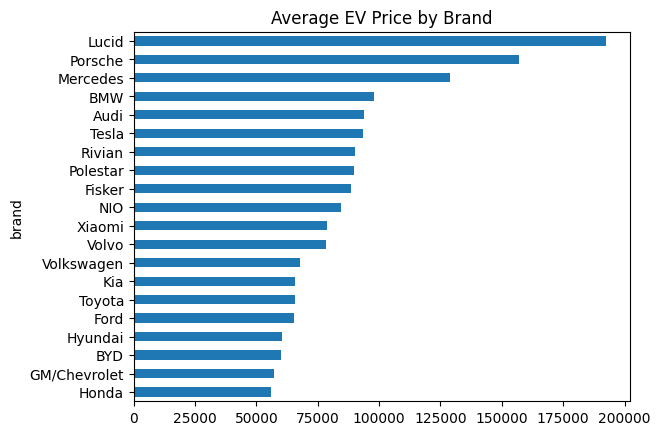

In [11]:
import matplotlib.pyplot as plt

avg_price = (
    df.groupby("brand")["price_usd"]
    .mean()
    .sort_values()
)

avg_price.plot(kind="barh")

plt.title("Average EV Price by Brand")
plt.show()

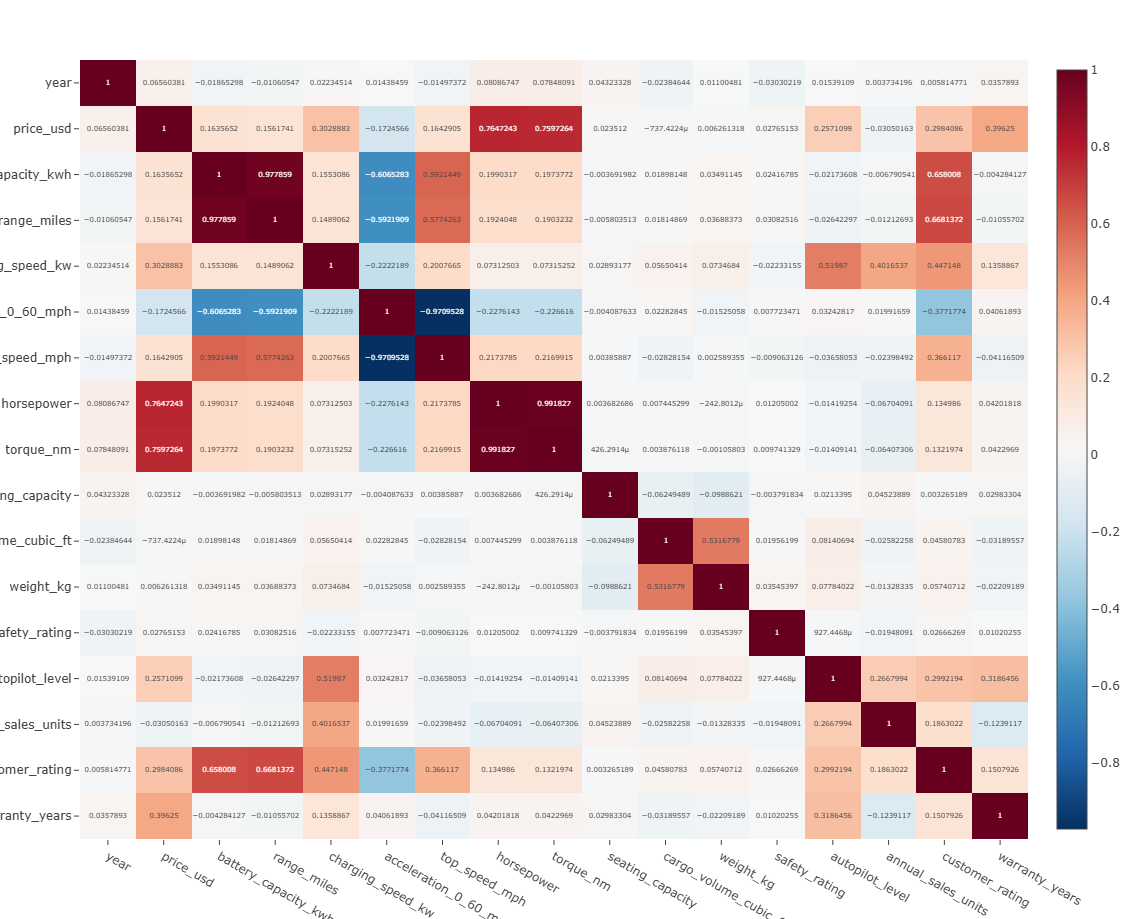

In [12]:
import plotly.express as px

corelasi_df = df.select_dtypes(include='number')
corr = corelasi_df.corr()
# heatmap
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
    color_continuous_scale='RdBu_r'
)
fig.update_layout(
    width=1200,
    height=900
)

fig.show()

In [13]:
corr_price = corr["price_usd"]

strong_corr = corr_price[
    (corr_price >= 0.5) &
    (corr_price <= 1)
]

print(strong_corr.sort_values(ascending=False))

price_usd     1.000000
horsepower    0.764724
torque_nm     0.759726
Name: price_usd, dtype: float64


In [14]:
avg_price = (
    df.groupby(['brand', 'variant'])[['price_usd']]
    .mean()
    .sort_values(by='price_usd', ascending=False)
    .reset_index()
)

print(avg_price)

           brand      variant      price_usd
0        Porsche  Performance  254017.080000
1          Lucid      Premium  247684.675000
2          Lucid     Standard  199365.900000
3          Lucid  Performance  161242.970000
4        Porsche     Standard  160851.840000
..           ...          ...            ...
90          Ford         Base   49751.074643
91           Kia         Base   48201.503429
92  GM/Chevrolet         Base   46384.720000
93           BYD         Base   45020.266875
94       Hyundai         Base   44794.130952

[95 rows x 3 columns]


In [15]:
top_sales = (
    df.groupby(['brand', 'variant'])[['annual_sales_units']]
    .sum()
    .sort_values(by='annual_sales_units', ascending=False)
    .reset_index()
)

print(top_sales)

       brand      variant  annual_sales_units
0      Tesla         Base            23581159
1      Tesla      Premium            22216189
2      Tesla   Long Range            20206469
3      Tesla     Standard            18308031
4      Tesla  Performance            17147634
..       ...          ...                 ...
90     Honda      Premium               10748
91     Volvo      Premium               10606
92     Honda  Performance                6885
93  Polestar   Long Range                5412
94  Polestar      Premium                3904

[95 rows x 3 columns]


In [16]:
df.groupby('brand')[['variant']].count()

,variant
brand,
Audi,77
BMW,150
BYD,282
Fisker,25
Ford,129
GM/Chevrolet,143
Honda,2
Hyundai,152
Kia,166


In [17]:
max_warranty = (
    df.groupby(['brand'])[['warranty_years']]
    .mean()
    .sort_values(by='warranty_years', ascending=False)
    .reset_index()
)

print(max_warranty)


           brand  warranty_years
0        Porsche        6.642857
1       Mercedes        6.520833
2           Audi        6.493506
3            BMW        6.420000
4         Rivian        4.918919
5          Tesla        4.914747
6          Lucid        4.833333
7         Fisker        4.280000
8            NIO        4.173913
9          Volvo        4.000000
10         Honda        4.000000
11  GM/Chevrolet        3.930070
12           BYD        3.918440
13           Kia        3.915663
14          Ford        3.883721
15    Volkswagen        3.881443
16        Xiaomi        3.875000
17       Hyundai        3.835526
18        Toyota        3.780488
19      Polestar        3.666667


In [18]:
top_aupilot = (
    df.groupby(['brand'])[['autopilot_level']]
    .mean()
    .sort_values(by='autopilot_level', ascending=False)
    .reset_index()
)
print(top_aupilot)

           brand  autopilot_level
0          Tesla         2.274194
1          Honda         1.500000
2            BMW         1.446667
3           Audi         1.428571
4       Mercedes         1.375000
5        Porsche         0.857143
6         Fisker         0.840000
7          Volvo         0.833333
8         Xiaomi         0.750000
9        Hyundai         0.703947
10          Ford         0.697674
11        Rivian         0.675676
12  GM/Chevrolet         0.657343
13    Volkswagen         0.634021
14           Kia         0.632530
15           BYD         0.588652
16           NIO         0.565217
17      Polestar         0.555556
18         Lucid         0.500000
19        Toyota         0.487805


In [19]:
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


In [20]:
!pip install pycountry


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\refitr082210\AppData\Local\Temp\ipykernel_19044\3771809300.py:8: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


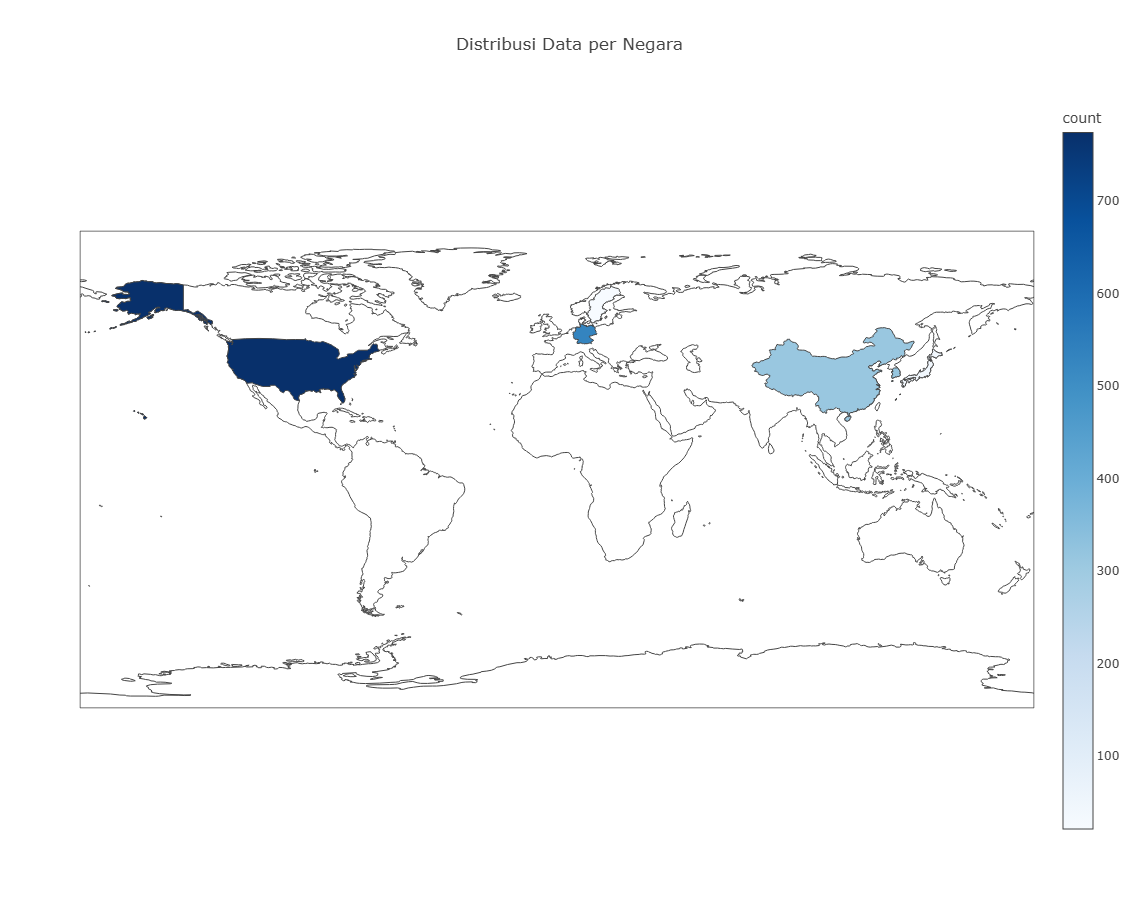

In [21]:
import plotly.express as px
import pycountry

avg_country = df.groupby("country_of_origin", as_index=False)["annual_sales_units"].count() 
avg_country = avg_country.rename(columns={"annual_sales_units": "count"}) 

#geo
fig = px.choropleth(
    avg_country,
    locations="country_of_origin", #kolom negara
    locationmode="country names", #baca negara
    color="count",
    color_continuous_scale="Blues",
    title="Distribusi Data per Negara") 

fig.update_layout(
    width=1200,
    height=900
)

fig.show()

In [22]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook"
import plotly.express as px

avg_country = df.groupby("country_of_origin", as_index=False)["annual_sales_units"].count()

fig = px.bar(avg_country,
             x="country_of_origin", 
             y="annual_sales_units")

fig.update_layout(title="Average Sales by Country")

fig.show()

In [24]:
df["brand"].value_counts()

brand
Tesla           434
BYD             282
Volkswagen      194
Kia             166
Hyundai         152
BMW             150
GM/Chevrolet    143
Ford            129
Mercedes         96
Audi             77
Toyota           41
Rivian           37
Fisker           25
NIO              23
Porsche          14
Volvo            12
Polestar          9
Xiaomi            8
Lucid             6
Honda             2
Name: count, dtype: int64

In [25]:
def show_fig():
    plt.tight_layout()
    plt.show()
plot_no = 1

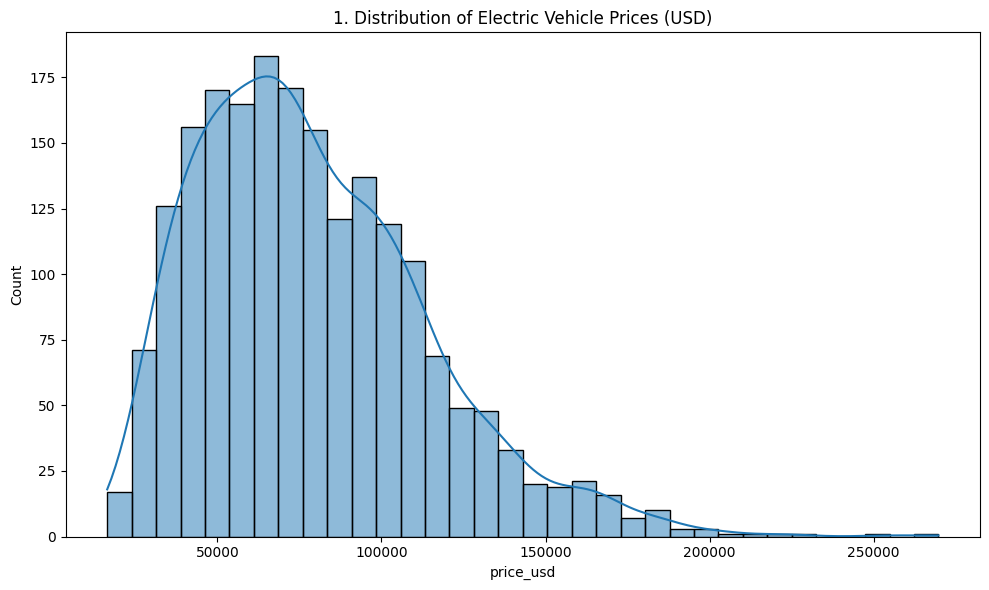

In [26]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['price_usd'], kde=True)
plt.title(f'{plot_no}. Distribution of Electric Vehicle Prices (USD)')
show_fig()
plot_no += 1

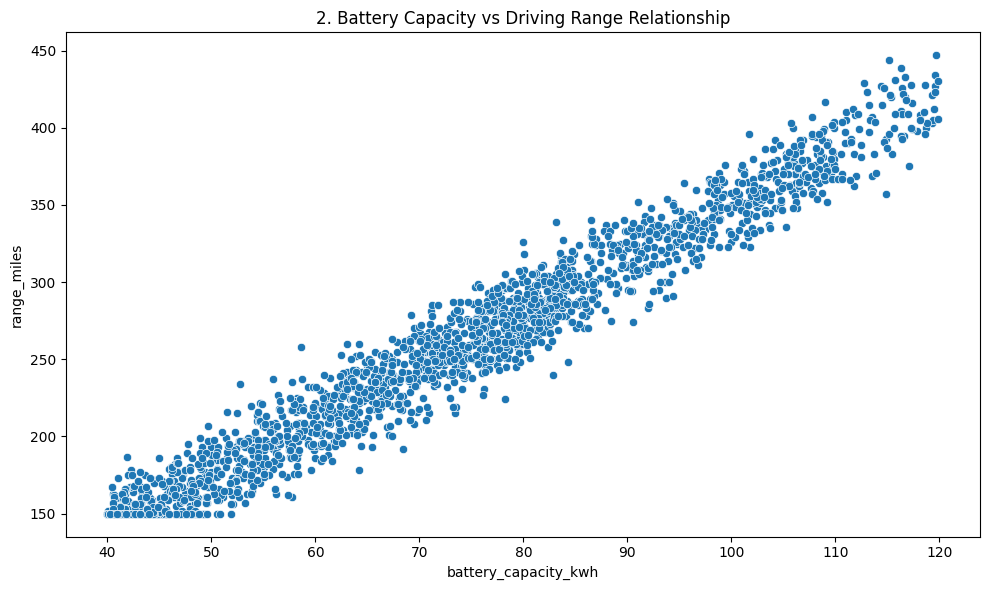

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='battery_capacity_kwh', y='range_miles', data=df)
plt.title(f'{plot_no}. Battery Capacity vs Driving Range Relationship')
show_fig()
plot_no += 1

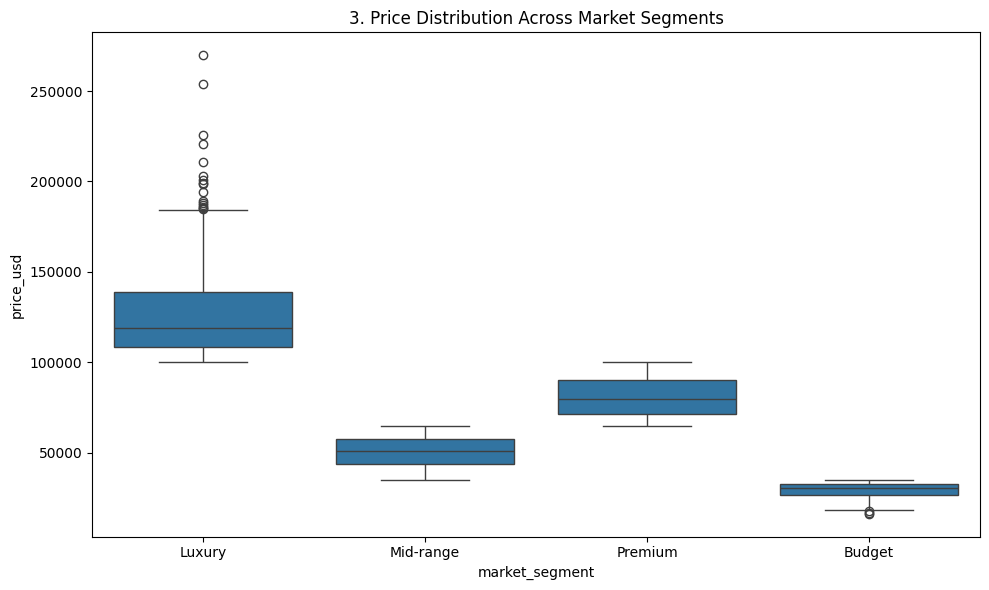

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='market_segment', y='price_usd', data=df)
plt.title(f'{plot_no}. Price Distribution Across Market Segments')
show_fig()
plot_no += 1

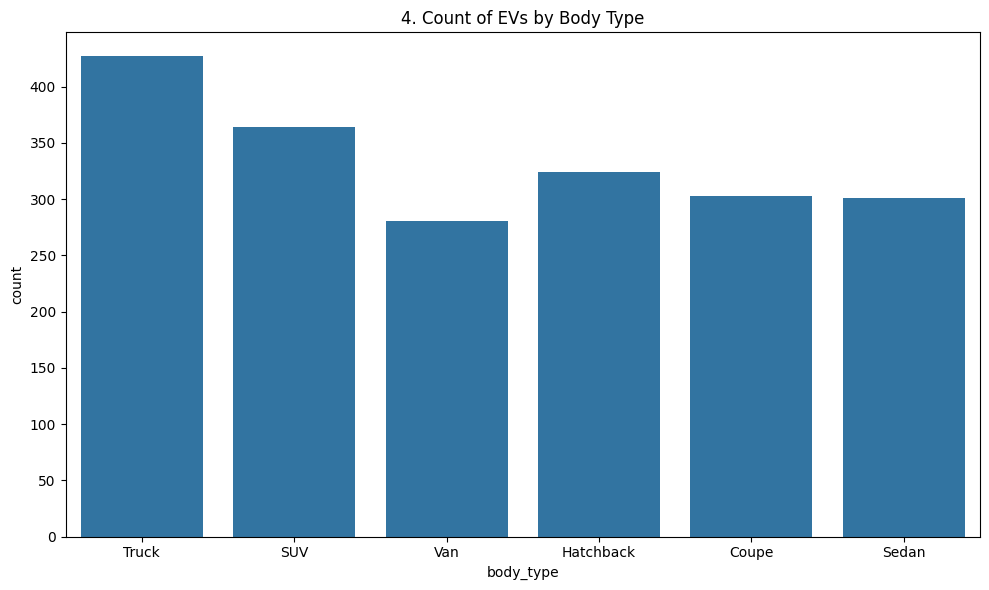

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='body_type', data=df)
plt.title(f'{plot_no}. Count of EVs by Body Type')
show_fig()
plot_no += 1

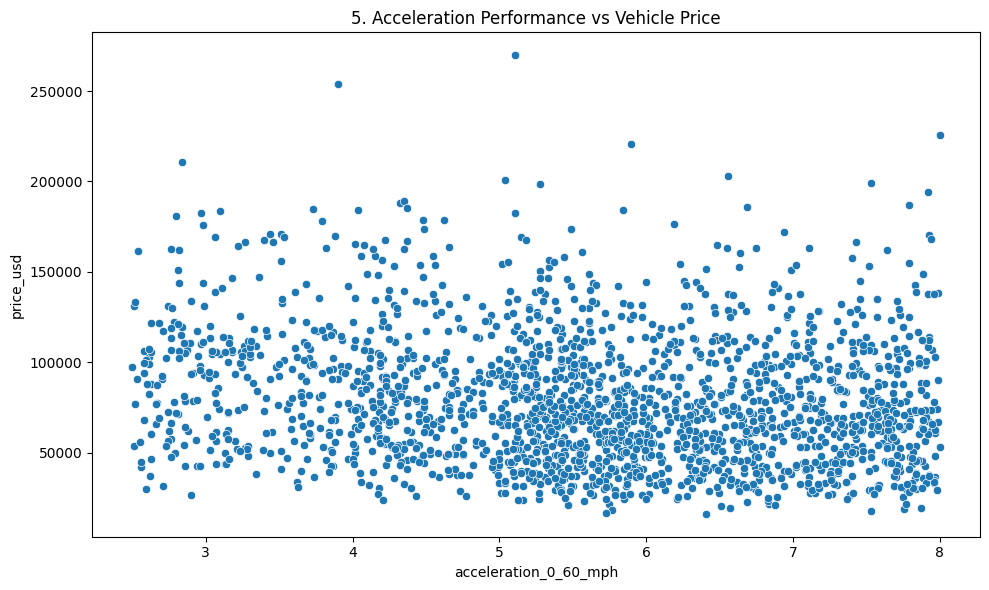

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='acceleration_0_60_mph', y='price_usd', data=df)
plt.title(f'{plot_no}. Acceleration Performance vs Vehicle Price')
show_fig()
plot_no += 1

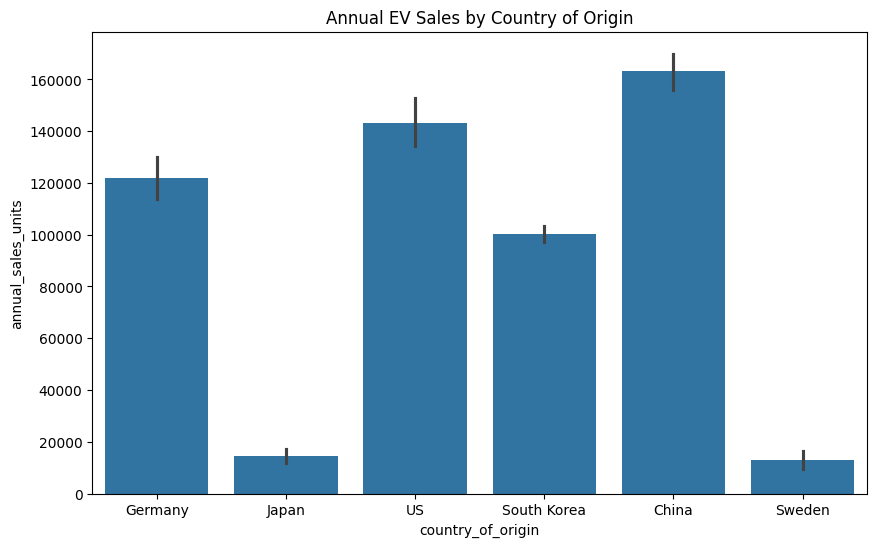

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='country_of_origin',
    y='annual_sales_units',
    data=df
)

plt.title('Annual EV Sales by Country of Origin')

plt.show()

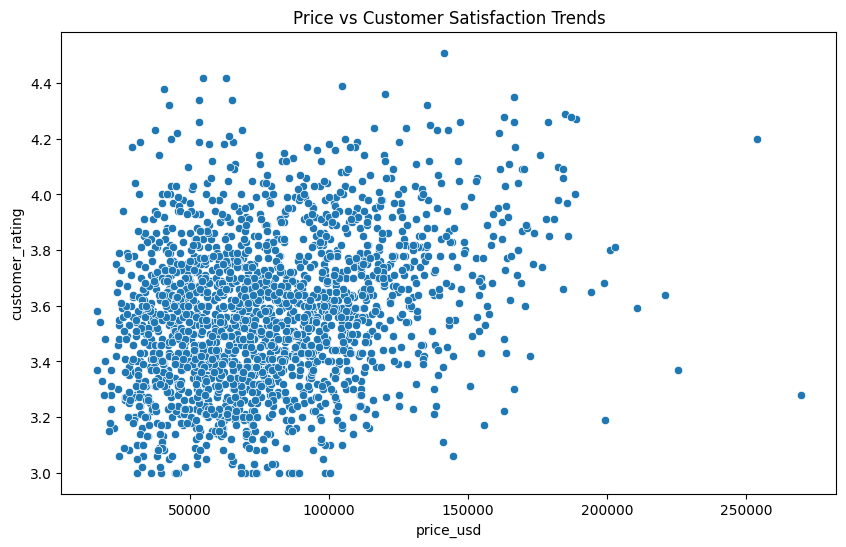

In [32]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='price_usd', y='customer_rating', data=df)
plt.title('Price vs Customer Satisfaction Trends')
plt.show()

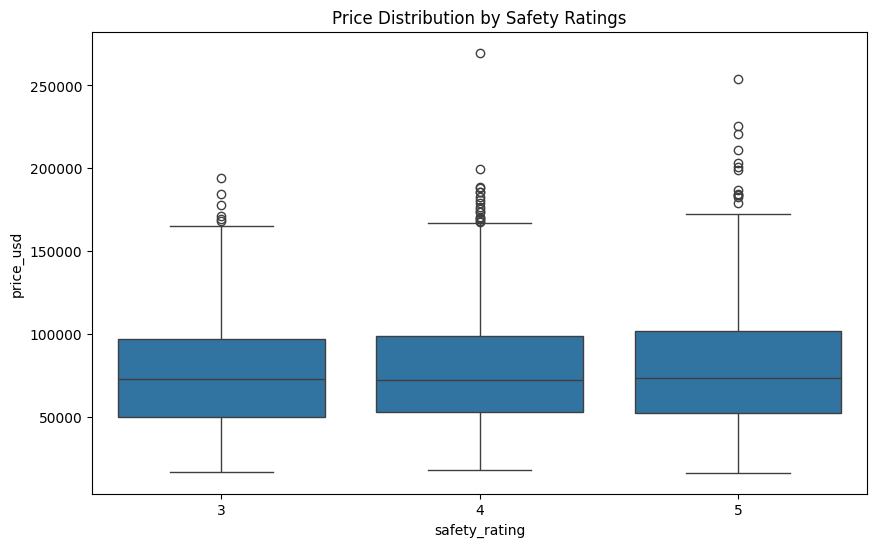

In [33]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='safety_rating', y='price_usd', data=df)
plt.title('Price Distribution by Safety Ratings')
plt.show()





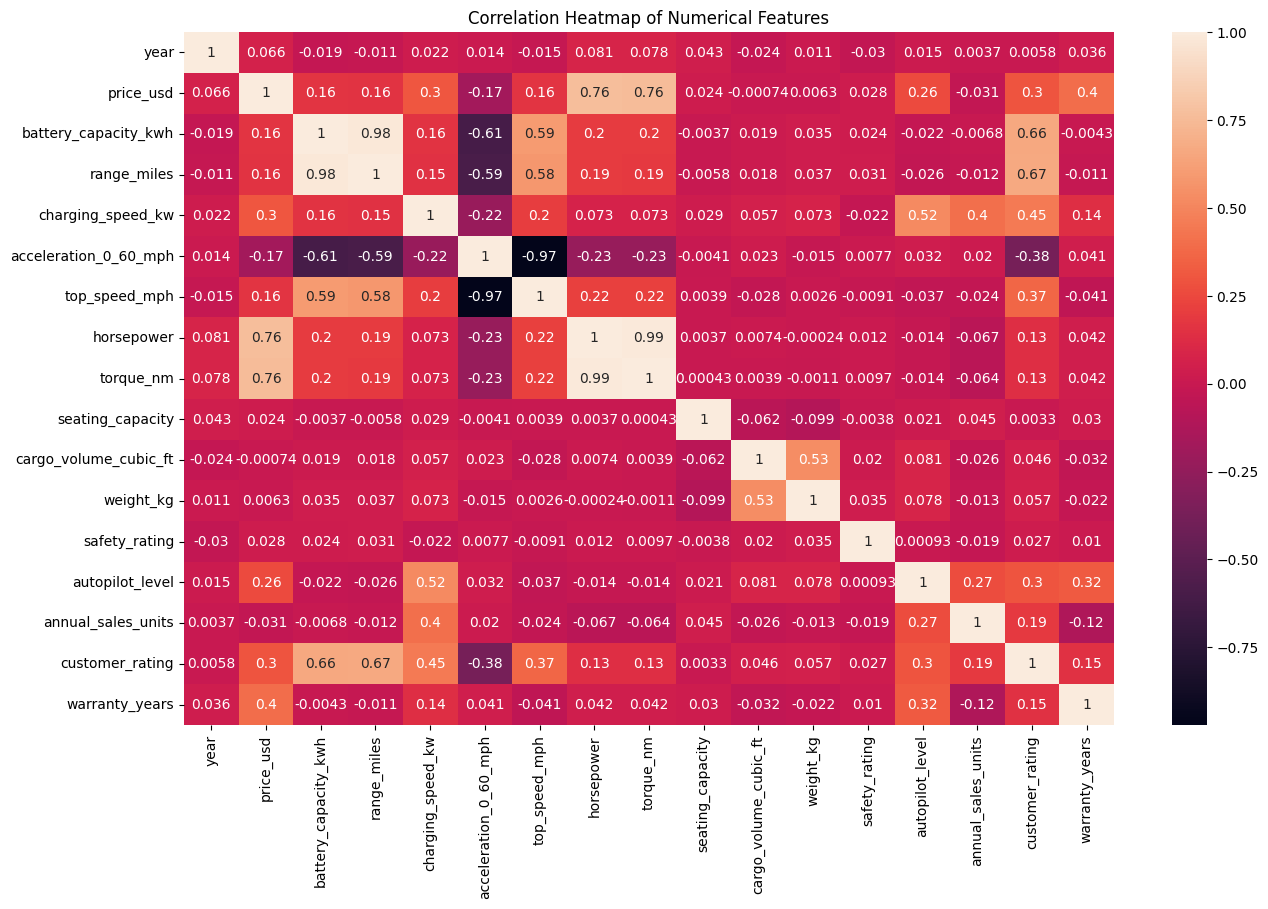

In [34]:
fig = plt.figure(figsize=(15, 9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


#Mendekati 1	sangat berhubungan
#Mendekati 0	tidak ada hubungan
#Mendekati -1	berhubungan tapi berlawanan

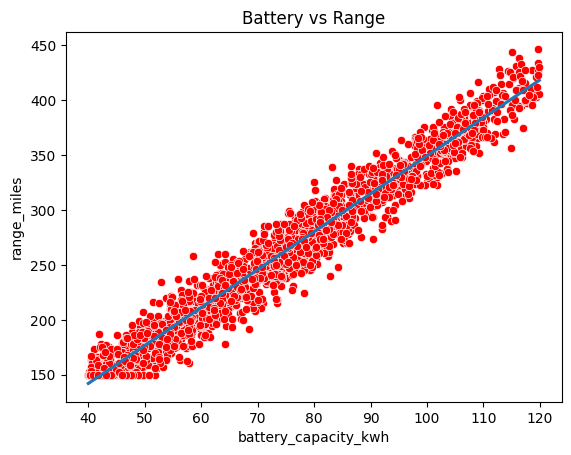

In [35]:
plt.figure()
sns.scatterplot(x='battery_capacity_kwh', y='range_miles', data=df, color='red')
sns.regplot(x='battery_capacity_kwh', y='range_miles', data=df, scatter=False)
plt.title("Battery vs Range")
plt.show()

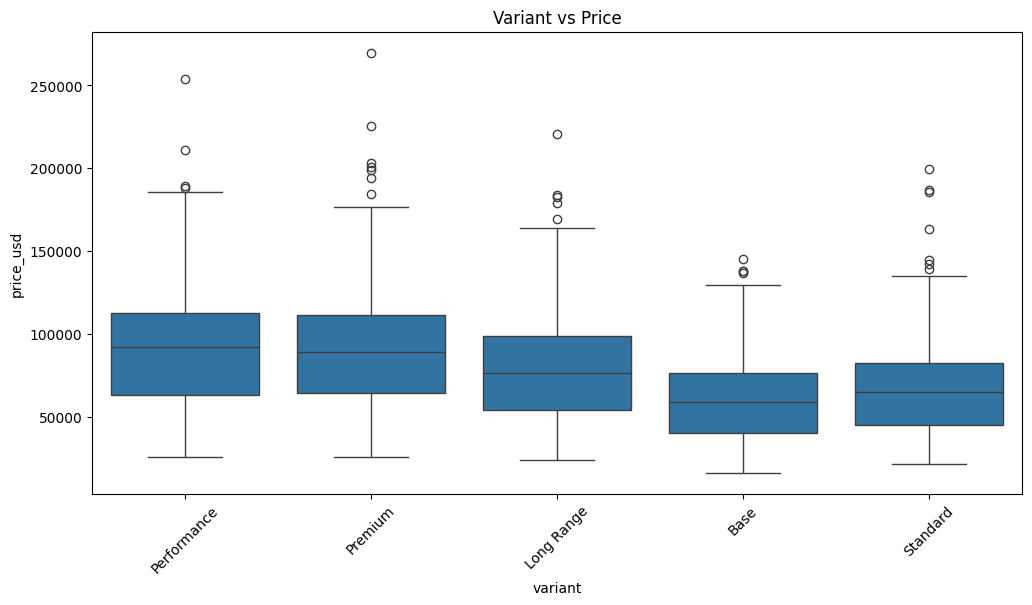

In [36]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='variant',
    y='price_usd',
    data=df
)

plt.title("Variant vs Price")

plt.xticks(rotation=45)

plt.show()

C:\Users\refitr082210\AppData\Local\Temp\ipykernel_19044\3602345962.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


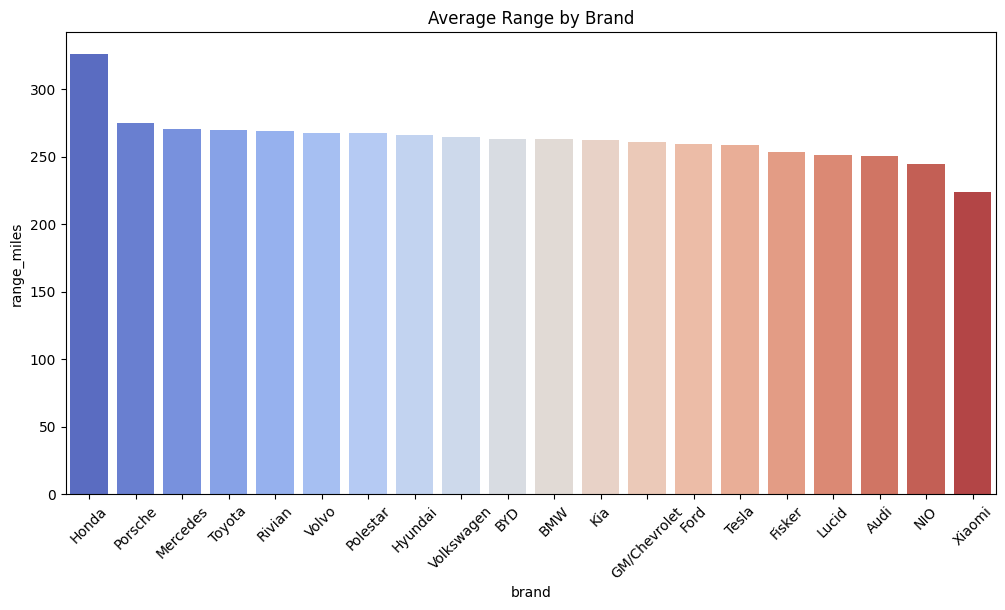

In [37]:
brand_stats = df.groupby('brand')[[
    'price_usd',
    'range_miles',
    'charging_speed_kw',
    'annual_sales_units'
]].mean().reset_index()
brand_stats_sorted = brand_stats.sort_values(by='range_miles', ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    data=brand_stats_sorted,
    x='brand',
    y='range_miles',
    palette='coolwarm'
)

plt.xticks(rotation=45)
plt.title("Average Range by Brand")
plt.show()


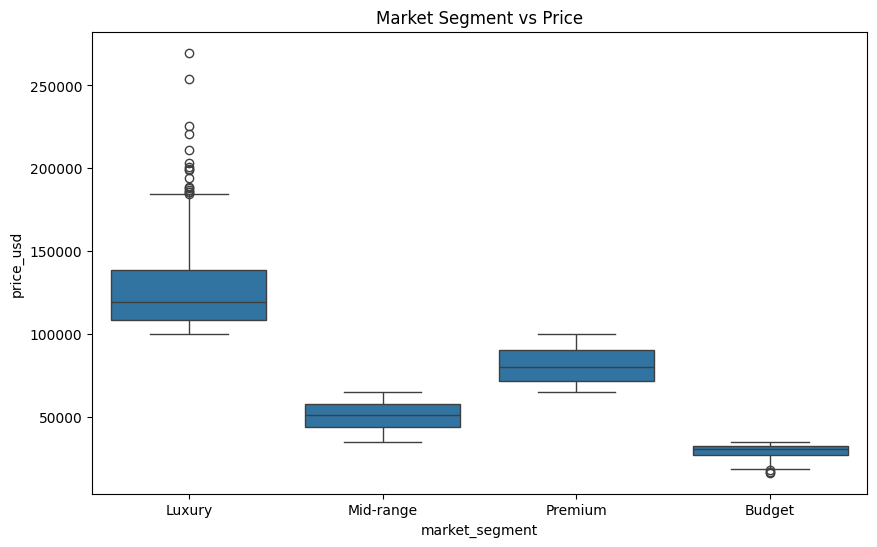

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='market_segment',
    y='price_usd',
    data=df
)

plt.title("Market Segment vs Price")

plt.show()

C:\Users\refitr082210\AppData\Local\Temp\ipykernel_19044\310350957.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


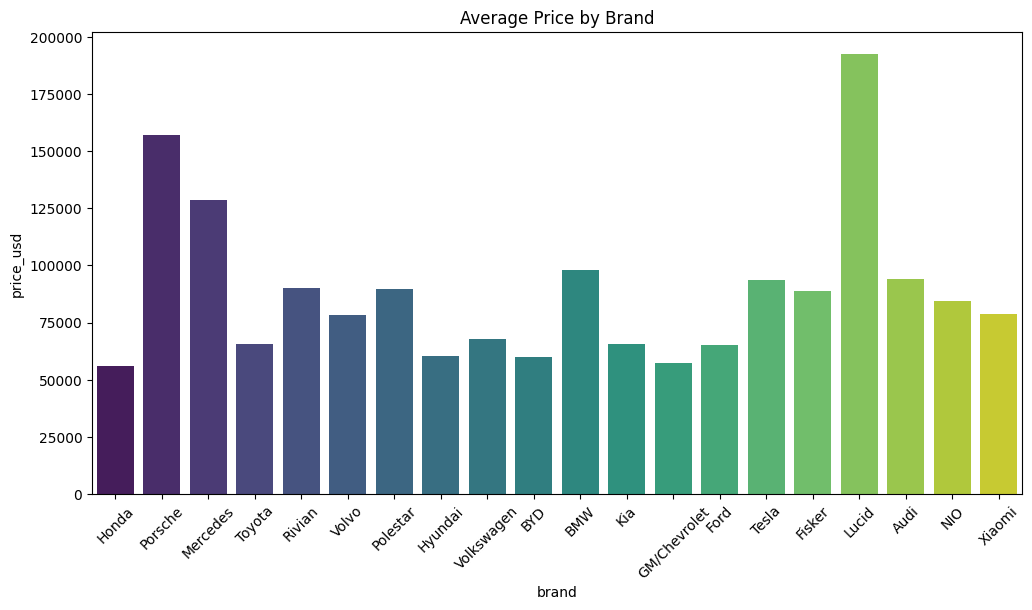

In [39]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=brand_stats_sorted,
    x='brand',
    y='price_usd',
    palette='viridis'
)

plt.xticks(rotation=45)
plt.title("Average Price by Brand")
plt.show()

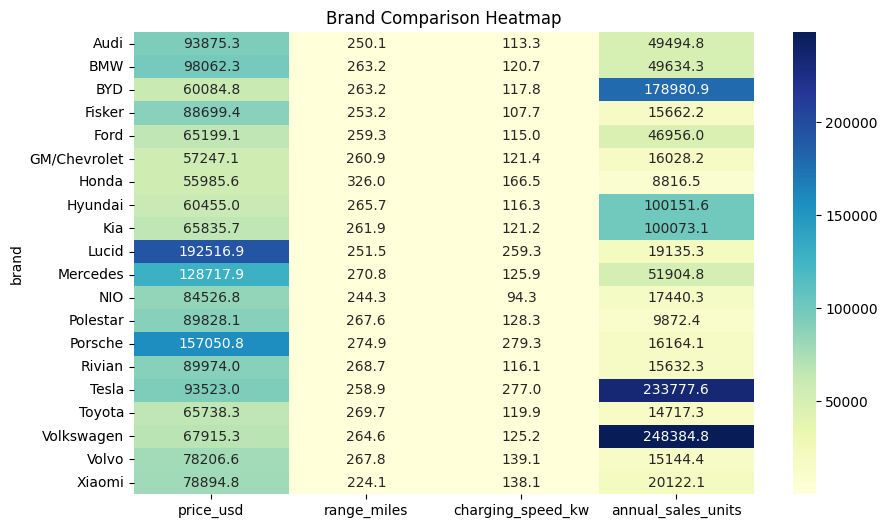

In [40]:
brand_heatmap = brand_stats.set_index('brand')

plt.figure(figsize=(10,6))

sns.heatmap(
    brand_heatmap,
    annot=True,
    cmap='YlGnBu',
    fmt='.1f'
)

plt.title("Brand Comparison Heatmap")
plt.show()

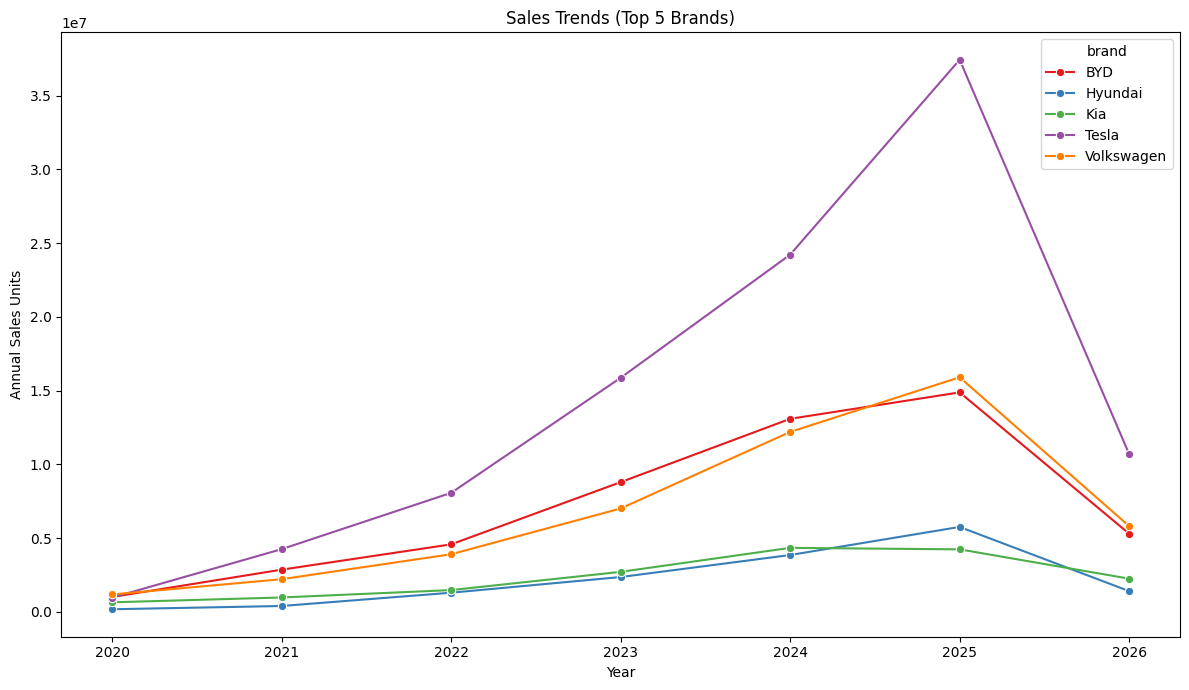

In [41]:
# ALWAYS define sales before plotting
sales = df.groupby(['year','brand'])['annual_sales_units'].sum().reset_index()

# Use top brands only (cleaner + prevents clutter issues)
top_brands = df.groupby('brand')['annual_sales_units'].sum().nlargest(5).index
filtered_sales = sales[sales['brand'].isin(top_brands)]

plt.figure(figsize=(12,7))

sns.lineplot(
    data=filtered_sales,
    x='year',
    y='annual_sales_units',
    hue='brand',
    marker='o',
    palette='Set1'
)

plt.title("Sales Trends (Top 5 Brands)")
plt.xlabel("Year")
plt.ylabel("Annual Sales Units")

plt.tight_layout()
plt.show()

In [42]:
df['value_score'] = df['range_miles'] / df['price_usd']

top_value = df.sort_values(by='value_score', ascending=False).head(10)

top_value[['brand','model','price_usd','range_miles','value_score']]

,brand,model,price_usd,range_miles,value_score
852,BYD,Qin,17777.32,280.0,0.015750
158,BYD,Seagull,19470.99,291.0,0.014945
1055,BYD,Seagull,16613.01,237.0,0.014266
1533,BYD,Qin,27057.77,385.0,0.014229
124,BYD,Qin,21712.40,307.0,0.014139
1775,BYD,Atto 3,26097.55,367.0,0.014063
1878,BYD,Atto 3,25253.73,355.0,0.014057
830,BYD,Atto 3,31933.47,430.0,0.013465
1021,BYD,Leaf 50X,25921.47,344.0,0.013271
617,BYD,Dolphin,19398.19,255.0,0.013146


C:\Users\refitr082210\AppData\Local\Temp\ipykernel_19044\1170112639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='value_score', y='model', data=top_value, palette='viridis')


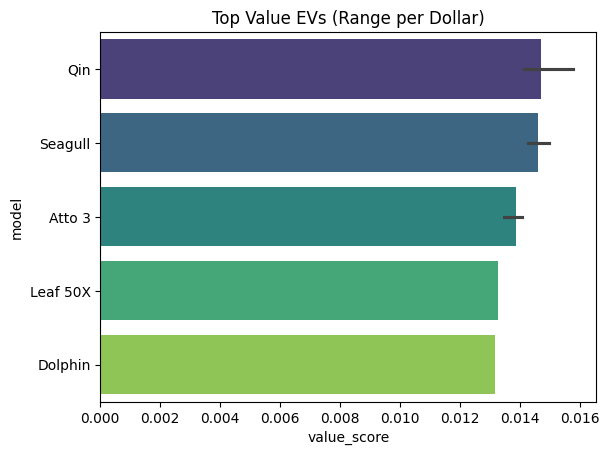

In [43]:
plt.figure()
sns.barplot(x='value_score', y='model', data=top_value, palette='viridis')
plt.title("Top Value EVs (Range per Dollar)")
plt.show()

In [46]:
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years,value_score
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4,0.003814
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3,0.004542
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3,0.004532
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3,0.009153
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,38.3,2229.0,4,2,US,Luxury,196401,3.83,4,0.002179


In [47]:
total_sales = df["annual_sales_units"].sum()
print(total_sales)

259307184


In [51]:
avg_range = df["range_miles"].mean()
print(avg_range)

261.8255
